In [1]:
import pandas as pd
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root:", project_root)
print("src exists:", (project_root / "src").exists())

Project root: c:\University\Year4\Thesis\AML-Thesis
src exists: True


In [ ]:
from src.risk_scoring import run_wallet_risk_scoring
from src.xai import run_shap_random_forest
from src.xai import run_local_shap_random_forest


In [3]:
risk_result = run_wallet_risk_scoring()

=== Wallet Risk Scoring Metrics ===
                     dataset                   model  accuracy  precision  \
0  elliptic-wallets-combined  Random Forest balanced  0.989411   0.858527   

     recall        f1   roc_auc  
0  0.705976  0.774814  0.981216  

Wallet risk scores saved to: C:\University\Year4\Thesis\AML-Thesis\models\rq4_risk_scoring\wallet_risk_scoring


In [4]:
shap_result = run_shap_random_forest(dataset="elliptic-wallets-combined")

=== Random Forest Balanced Metrics ===
                     dataset                   model  accuracy  precision  \
0  elliptic-wallets-combined  Random Forest balanced  0.989411   0.858527   

     recall        f1   roc_auc  
0  0.705976  0.774814  0.981216  

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     47382
           1       0.86      0.71      0.77      1255

    accuracy                           0.99     48637
   macro avg       0.93      0.85      0.88     48637
weighted avg       0.99      0.99      0.99     48637


SHAP Random Forest results saved to: C:\University\Year4\Thesis\AML-Thesis\models\rq3_xai_models\feature_models\random_forest_shap_elliptic-wallets-combined


In [5]:
local_shap_result = run_local_shap_random_forest()

=== Random Forest Balanced Metrics ===
                     dataset                   model  accuracy  precision  \
0  elliptic-wallets-combined  Random Forest balanced  0.989411   0.858527   

     recall        f1   roc_auc  
0  0.705976  0.774814  0.981216  

Local SHAP results saved to: C:\University\Year4\Thesis\AML-Thesis\models\rq4_risk_scoring\feature_models\random_forest_local_shap_elliptic-wallets-combined


In [6]:
lime_result = run_lime_random_forest()

=== Random Forest Balanced Metrics ===
                     dataset                   model  accuracy  precision  \
0  elliptic-wallets-combined  Random Forest balanced  0.989411   0.858527   

     recall        f1   roc_auc  
0  0.705976  0.774814  0.981216  


c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not 


LIME results saved to: C:\University\Year4\Thesis\AML-Thesis\models\rq4_risk_scoring\feature_models\random_forest_lime_elliptic-wallets-combined


c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [7]:
counterfactual_result = run_counterfactual_random_forest()

=== Random Forest Balanced Metrics ===
                     dataset                   model  accuracy  precision  \
0  elliptic-wallets-combined  Random Forest balanced  0.989411   0.858527   

     recall        f1   roc_auc  
0  0.705976  0.774814  0.981216  

Counterfactual results saved to: C:\University\Year4\Thesis\AML-Thesis\models\rq4_risk_scoring\feature_models\random_forest_counterfactual_elliptic-wallets-combined


In [8]:
from src.risk_scoring import build_compliance_output, save_compliance_output

compliance_df = build_compliance_output(
    risk_scores_df=risk_result["risk_scores"],
    shap_df=shap_result["importance"],
    lime_df=lime_result["lime_explanations"],
    counterfactual_df=counterfactual_result["counterfactuals"],
    top_n_explanations=3,
)

save_compliance_output(compliance_df)

compliance_df.head(10)

Compliance output saved to: C:\University\Year4\Thesis\AML-Thesis\models\rq4_risk_scoring\wallet_risk_scoring\compliance_output.csv


,wallet_index,true_label,predicted_label,fraud_probability,risk_score,risk_level,recommended_action,top_shap_drivers,top_lime_drivers,counterfactual_recommendation
200663,200663,1,1,1.0,100.0,Critical,Prioritize for compliance investigation,transacted_w_address_total; first_sent_block; ...,fees_mean > 0.01; fees_median > 0.01; blocks_b...,Changing blocks_btwn_txs_max from 1.0 to 0.0 r...
200781,200781,1,1,1.0,100.0,Critical,Prioritize for compliance investigation,transacted_w_address_total; first_sent_block; ...,transacted_w_address_min <= 1.00; fees_mean > ...,Changing blocks_btwn_txs_max from 4.0 to 0.0 r...
200792,200792,1,1,1.0,100.0,Critical,Prioritize for compliance investigation,transacted_w_address_total; first_sent_block; ...,first_sent_block > 449664.00; first_received_b...,Changing blocks_btwn_txs_median from 6.0 to 0....
197154,197154,1,1,1.0,100.0,Critical,Prioritize for compliance investigation,transacted_w_address_total; first_sent_block; ...,fees_as_share_median > 0.00; fees_as_share_min...,Changing fees_median from 0.0002 to 0.00180925...
197156,197156,1,1,1.0,100.0,Critical,Prioritize for compliance investigation,transacted_w_address_total; first_sent_block; ...,1.00 < transacted_w_address_total <= 2.00; fee...,Changing lifetime_in_blocks from 3.0 to 0.0 re...
197225,197225,1,1,1.0,100.0,Critical,Prioritize for compliance investigation,transacted_w_address_total; first_sent_block; ...,first_sent_block > 449664.00; fees_as_share_ma...,Changing btc_received_total from 0.0049 to 0.0...
205563,205563,1,1,1.0,100.0,Critical,Prioritize for compliance investigation,transacted_w_address_total; first_sent_block; ...,1.00 < transacted_w_address_total <= 2.00; fee...,Changing lifetime_in_blocks from 1.0 to 0.0 re...
195298,195298,1,1,1.0,100.0,Critical,Prioritize for compliance investigation,transacted_w_address_total; first_sent_block; ...,fees_as_share_median > 0.00; fees_as_share_min...,Changing fees_as_share_total from 0.0003442433...
205577,205577,1,1,1.0,100.0,Critical,Prioritize for compliance investigation,transacted_w_address_total; first_sent_block; ...,1.00 < transacted_w_address_total <= 2.00; fee...,Changing fees_min from 0.0001 to 0.0015755 red...
205660,205660,1,1,1.0,100.0,Critical,Prioritize for compliance investigation,transacted_w_address_total; first_sent_block; ...,first_received_block > 453697.00; first_sent_b...,Changing num_txs_as_sender from 1.0 to 0.0 red...


## **Behavioural Pattern Analysis**

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load RQ4 outputs
risk_scores = pd.read_csv("../models/rq4_risk_scoring/wallet_risk_scoring/wallet_risk_scores.csv")
local_shap = pd.read_csv("../models/rq4_risk_scoring/feature_models/random_forest_local_shap_elliptic-wallets-combined/local_shap_explanations.csv")
lime = pd.read_csv("../models/rq4_risk_scoring/feature_models/random_forest_lime_elliptic-wallets-combined/lime_explanations.csv")
counterfactuals = pd.read_csv("../models/rq4_risk_scoring/feature_models/random_forest_counterfactual_elliptic-wallets-combined/counterfactual_explanations.csv")

In [13]:
pattern_map = {
    "Fee behaviour": [
        "fees_min", "fees_max", "fees_mean", "fees_median", "fees_total",
        "fees_as_share_min", "fees_as_share_max", "fees_as_share_mean",
        "fees_as_share_median", "fees_as_share_total"
    ],
    "Transaction timing": [
        "blocks_btwn_txs_min", "blocks_btwn_txs_max", "blocks_btwn_txs_mean",
        "blocks_btwn_txs_median", "lifetime_in_blocks"
    ],
    "Counterparty interaction": [
        "transacted_w_address_total"
    ],
    "Temporal blockchain activity": [
        "first_sent_block", "first_received_block",
        "first_block_appeared_in", "last_block_appeared_in"
    ],
    "BTC transfer behaviour": [
        "btc_sent_min", "btc_sent_max", "btc_sent_mean", "btc_sent_median", "btc_sent_total",
        "btc_received_min", "btc_received_max", "btc_received_mean",
        "btc_received_median", "btc_received_total"
    ],
    "Transaction volume": [
        "total_txs", "num_txs_as_sender", "num_txs_as_receiver"
    ]
}

def map_pattern(feature_name):
    feature_name = str(feature_name)

    for pattern, features in pattern_map.items():
        for feature in features:
            if feature in feature_name:
                return pattern

    return "Other"

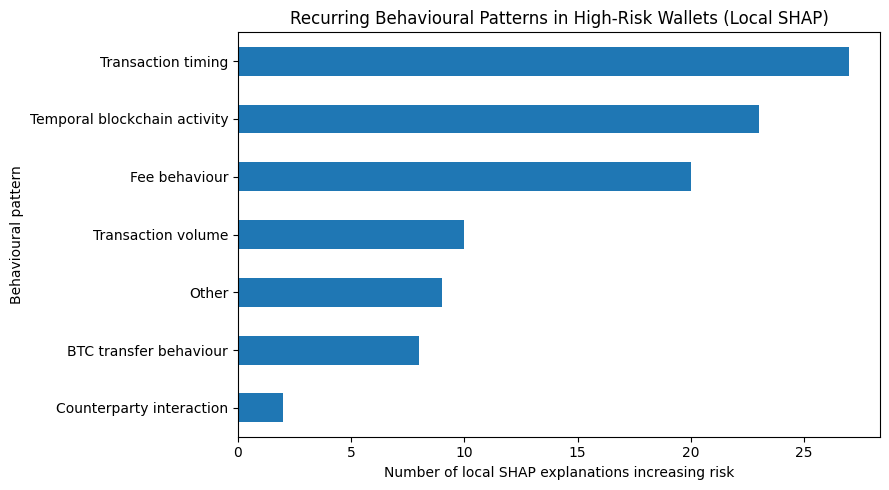

behaviour_pattern
Transaction timing              27
Temporal blockchain activity    23
Fee behaviour                   20
Transaction volume              10
Other                            9
BTC transfer behaviour           8
Counterparty interaction         2
dtype: int64

In [25]:
local_shap["behaviour_pattern"] = local_shap["feature"].apply(map_pattern)

shap_patterns = (
    local_shap[local_shap["direction"] == "increases risk"]
    .groupby("behaviour_pattern")
    .size()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))
shap_patterns.plot(kind="barh")
plt.xlabel("Number of local SHAP explanations increasing risk")
plt.ylabel("Behavioural pattern")
plt.title("Recurring Behavioural Patterns in High-Risk Wallets (Local SHAP)")
plt.tight_layout()
plt.savefig("../models/rq4_risk_scoring/feature_models/random_forest_local_shap_elliptic-wallets-combined/local_shap_behavioural_patterns.png", dpi=150)
plt.show()

shap_patterns.sort_values(ascending=False)

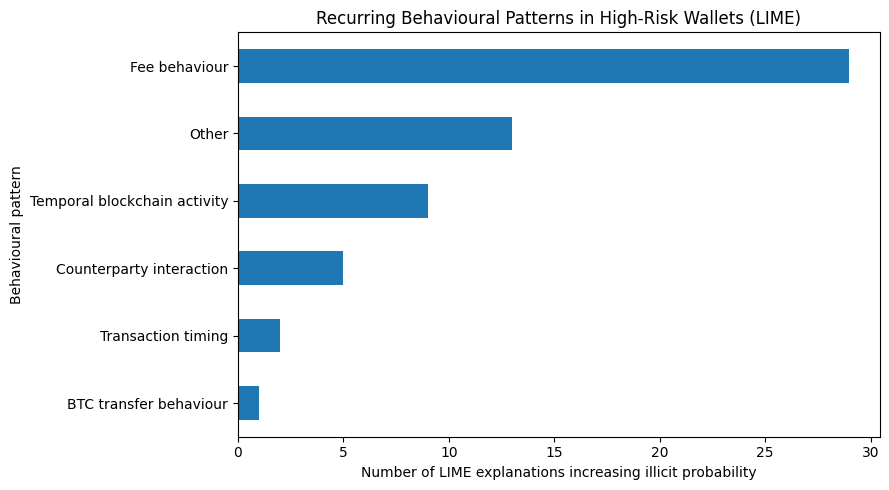

behaviour_pattern
Fee behaviour                   29
Other                           13
Temporal blockchain activity     9
Counterparty interaction         5
Transaction timing               2
BTC transfer behaviour           1
dtype: int64

In [27]:
lime["behaviour_pattern"] = lime["feature_rule"].apply(map_pattern)

lime_patterns = (
    lime[lime["lime_importance"] > 0]
    .groupby("behaviour_pattern")
    .size()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))
lime_patterns.plot(kind="barh")
plt.xlabel("Number of LIME explanations increasing illicit probability")
plt.ylabel("Behavioural pattern")
plt.title("Recurring Behavioural Patterns in High-Risk Wallets (LIME)")
plt.tight_layout()
plt.savefig("../models/rq4_risk_scoring/feature_models/random_forest_lime_elliptic-wallets-combined/lime_behavioural_patterns.png", dpi=150)
plt.show()

lime_patterns.sort_values(ascending=False)

In [16]:
counterfactuals["behaviour_pattern"] = counterfactuals["feature_changed"].apply(map_pattern)

cf_patterns = (
    counterfactuals
    .groupby("behaviour_pattern")["risk_score_reduction"]
    .agg(["count", "mean", "max"])
    .sort_values("mean", ascending=False)
)

cf_patterns

,count,mean,max
behaviour_pattern,,,
BTC transfer behaviour,2,98.750000,99.0
Transaction timing,8,90.812500,93.0
Other,2,87.250000,88.5
Temporal blockchain activity,11,84.727273,98.0
Transaction volume,2,84.500000,98.5
Fee behaviour,25,77.440000,98.0


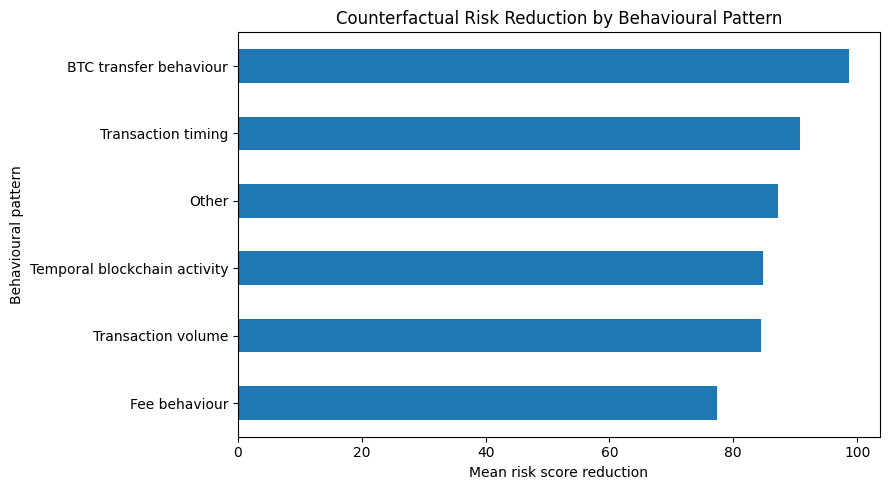

In [28]:
cf_patterns_plot = cf_patterns["mean"].sort_values(ascending=True)

plt.figure(figsize=(9, 5))
cf_patterns_plot.plot(kind="barh")
plt.xlabel("Mean risk score reduction")
plt.ylabel("Behavioural pattern")
plt.title("Counterfactual Risk Reduction by Behavioural Pattern")
plt.tight_layout()
plt.savefig("../models/rq4_risk_scoring/feature_models/random_forest_counterfactual_elliptic-wallets-combined/counterfactual_behavioural_patterns.png", dpi=150)
plt.show()

In [29]:
combined_patterns = pd.DataFrame({
    "local_shap_count": shap_patterns,
    "lime_count": lime_patterns,
    "counterfactual_count": cf_patterns["count"],
    "mean_counterfactual_reduction": cf_patterns["mean"],
}).fillna(0)

combined_patterns = combined_patterns.sort_values(
    ["local_shap_count", "lime_count", "mean_counterfactual_reduction"],
    ascending=False
)

combined_patterns.to_csv("../models/rq4_risk_scoring/combined_patterns.csv", index=True)

combined_patterns

,local_shap_count,lime_count,counterfactual_count,mean_counterfactual_reduction
behaviour_pattern,,,,
Transaction timing,27,2.0,8.0,90.812500
Temporal blockchain activity,23,9.0,11.0,84.727273
Fee behaviour,20,29.0,25.0,77.440000
Transaction volume,10,0.0,2.0,84.500000
Other,9,13.0,2.0,87.250000
BTC transfer behaviour,8,1.0,2.0,98.750000
Counterparty interaction,2,5.0,0.0,0.000000


## **Visual 1: Recurring Behavioural Patterns Across Explainability Methods**

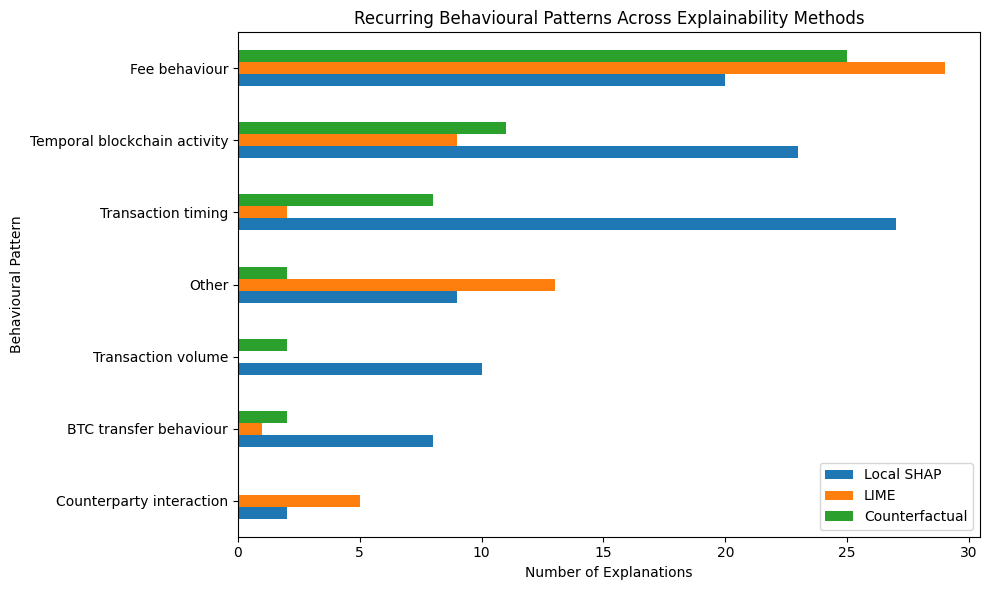

In [26]:
import matplotlib.pyplot as plt

# Select columns for plotting
plot_df = combined_patterns[
    ["local_shap_count", "lime_count", "counterfactual_count"]
].copy()

# Sort by overall importance
plot_df["total"] = plot_df.sum(axis=1)
plot_df = plot_df.sort_values("total", ascending=True)

# Remove helper column
plot_df = plot_df.drop(columns="total")

# Plot
ax = plot_df.plot(
    kind="barh",
    figsize=(10, 6),
)

plt.xlabel("Number of Explanations")
plt.ylabel("Behavioural Pattern")
plt.title("Recurring Behavioural Patterns Across Explainability Methods")
plt.legend([
    "Local SHAP",
    "LIME",
    "Counterfactual"
])

plt.tight_layout()
plt.savefig("../models/rq4_risk_scoring/figures/combined_behavioural_patterns.png", dpi=150)
plt.show()

## **Visual 2: Impact of Behavioural Changes on Wallet Risk Scores**

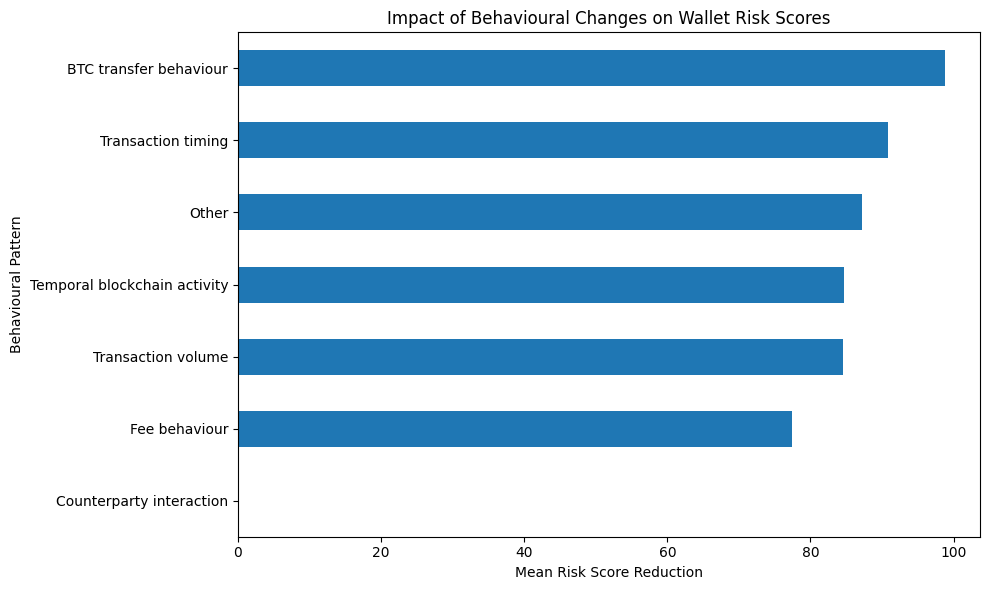

In [23]:
import matplotlib.pyplot as plt

# Sort by mean reduction
impact_plot = combined_patterns[
    "mean_counterfactual_reduction"
].sort_values(ascending=True)

# Plot
plt.figure(figsize=(10, 6))

impact_plot.plot(kind="barh")

plt.xlabel("Mean Risk Score Reduction")
plt.ylabel("Behavioural Pattern")
plt.title("Impact of Behavioural Changes on Wallet Risk Scores")

plt.tight_layout()
plt.savefig("../models/rq4_risk_scoring/figures/behavioural_impact_changes_wallet_risk_scores.png", dpi=150)
plt.show()

## **Statistical Analysis**

**Compare risk scores between licit and illicit wallets**

In [48]:
import pandas as pd

risk_scores = pd.read_csv(
    "../models/rq4_risk_scoring/wallet_risk_scoring/wallet_risk_scores.csv"
)

# Split by class
licit_scores = risk_scores[risk_scores["true_label"] == 0]["risk_score"]
illicit_scores = risk_scores[risk_scores["true_label"] == 1]["risk_score"]

# Summary statistics
stats_df = pd.DataFrame({
    "licit": [
        licit_scores.mean(),
        licit_scores.median(),
        licit_scores.std(),
        licit_scores.min(),
        licit_scores.max(),
    ],
    "illicit": [
        illicit_scores.mean(),
        illicit_scores.median(),
        illicit_scores.std(),
        illicit_scores.min(),
        illicit_scores.max(),
    ]
}, index=[
    "mean",
    "median",
    "std",
    "min",
    "max",
])

stats_df.to_csv("../models/rq4_risk_scoring/statistical_analysis/compared_risk_scores.csv")

stats_df

,licit,illicit
mean,1.615606,69.152816
median,0.000000,88.000000
std,5.684430,35.271837
min,0.000000,0.000000
max,98.000000,100.000000


**Mann–Whitney U test**

In [36]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    illicit_scores,
    licit_scores,
    alternative="greater"
)

print(f"Mann-Whitney U statistic: {stat:.4f}")
print(f"p-value: {p_value:.10e}")

Mann-Whitney U statistic: 58347432.0000
p-value: 0.0000000000e+00


p < 0.05 - illicit wallets have significantly higher risk scores than licit wallets.

## **Risk-level distribution**

In [50]:
risk_distribution = (
    risk_scores["risk_level"]
    .value_counts()
    .sort_index()
)

risk_distribution.to_csv("../models/rq4_risk_scoring/statistical_analysis/risk_distribution.csv")

risk_distribution

risk_level
Critical      783
High          256
Low         47060
Medium        538
Name: count, dtype: int64

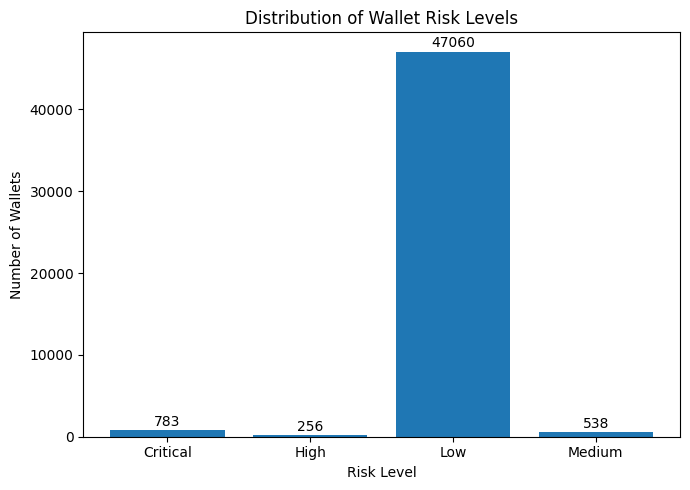

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

risk_distribution_dr = pd.read_csv(
    "../models/rq4_risk_scoring/statistical_analysis/risk_distribution.csv"
)

x = risk_distribution_dr["risk_level"]
y = risk_distribution_dr["count"]

ax = plt.bar(x, y)

# Add values above bars
for i, value in enumerate(y):
    plt.text(
        i,
        value + 500,
        str(value),
        ha='center',
        fontsize=10
    )

plt.ylabel("Number of Wallets")
plt.xlabel("Risk Level")
plt.title("Distribution of Wallet Risk Levels")

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(
    "../models/rq4_risk_scoring/statistical_analysis/wallet_risk_distribution.png"
)
plt.show()

## **Correlation analysis**

In [53]:
important_features = [
    "fees_max",
    "blocks_btwn_txs_max",
    "transacted_w_address_total",
    "first_sent_block",
    "btc_sent_total",
]

correlation_df = risk_scores[
    important_features + ["risk_score"]
].corr()

correlation_df.to_csv("../models/rq4_risk_scoring/statistical_analysis/correlation.csv")

correlation_df["risk_score"].sort_values(ascending=False)

risk_score                    1.000000
first_sent_block              0.208104
fees_max                      0.059620
btc_sent_total               -0.001696
transacted_w_address_total   -0.013808
blocks_btwn_txs_max          -0.019640
Name: risk_score, dtype: float64

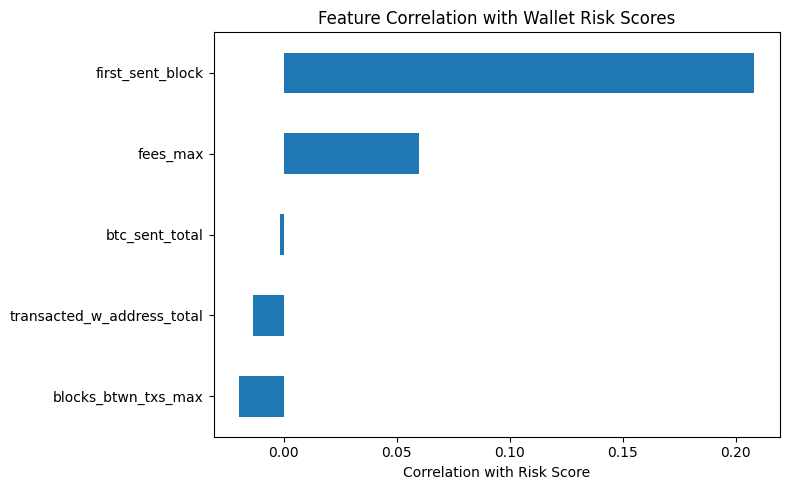

: 

In [ ]:
import matplotlib.pyplot as plt

corr_values = correlation_df["risk_score"][:-1].sort_values()

plt.figure(figsize=(8, 5))

corr_values.plot(kind="barh")

plt.xlabel("Correlation with Risk Score")
plt.title("Feature Correlation with Wallet Risk Scores")

plt.tight_layout()
plt.savefig("../models/rq4_risk_scoring/statistical_analysis/feature_wallet_risk_correlation.png")
plt.show()